<table style="width: 100%; border-collapse: collapse; border: none; background: #f8fafc; border-left: 6px solid #d97706; border-radius: 8px; padding: 20px; box-shadow: 0 2px 4px rgba(0,0,0,0.05);">
  <tr style="border: none;">
    <td style="vertical-align: middle; border: none; padding: 15px 20px;">
      <h1 style="margin: 0; color: #0f172a; font-size: 2.1em; font-family: system-ui, -apple-system, sans-serif; font-weight: 800; letter-spacing: -0.02em;">
        Calidad de Datos y Auditoría Multivariada 🔍🧹
      </h1>
      <p style="margin: 6px 0 0 0; color: #d97706; font-size: 1.15em; font-weight: 600; font-family: system-ui, -apple-system, sans-serif;">
        Especialización en Ciencia de Datos | Minería de Datos (Data Mining)
      </p>
      <p style="margin: 4px 0 0 0; color: #64748b; font-size: 0.95em; font-family: system-ui, -apple-system, sans-serif;">
        Universidad Santo Tomás — Seccional Tunja
      </p>
    </td>
    <td style="text-align: right; vertical-align: middle; border: none; padding: 15px 20px; width: 30%;">
      <span style="background: #d97706; color: #ffffff; padding: 6px 14px; border-radius: 20px; font-size: 0.85em; font-weight: 700; display: inline-block; margin-bottom: 8px;">
        Módulo 00 • Data Mining
      </span><br>
      <span style="color: #64748b; font-size: 0.85em;">Docente: Santiago A. Zúñiga M.</span><br>
      <a href="mailto:gestorvirtualcienciadatos@ustatunja.edu.co" style="color: #d97706; font-size: 0.8em; text-decoration: none; font-weight: 500;">gestorvirtualcienciadatos@ustatunja.edu.co</a>
    </td>
  </tr>
</table>

<div align="center" style="margin-top: 15px; margin-bottom: 15px;">
  <a href="https://colab.research.google.com/github/sazuniga06/Data-Science-Programming---USTA-Tunja-Repository/blob/main/Data%20Mining/00%20-%20Introduccion%20al%20Data%20Mining/03_Calidad_de_Datos_y_Exploracion_Multivariada.ipynb" target="_parent">
    <img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab" style="vertical-align: middle;"/>
  </a>
</div>

---
## 1. Los Cinco Pilares Fundamentales de la Calidad del Dato (*Data Quality*) 🏛️

El axioma más célebre de la computación y la analítica es **GIGO (*Garbage In, Garbage Out*)**: ningún algoritmo de Machine Learning, por sofisticado o profundo que sea, puede extraer patrones inteligentes a partir de datos corruptos, incompletos o inconsistentes.

De acuerdo con los estándares internacionales de gobernanza de datos (DAMA-DMBOK), la calidad se audita bajo cinco dimensiones esenciales:

| Dimensión | Pregunta de Control | Ejemplo de Defecto Crítico |
|---|---|---|
| **1. Completitud (*Completeness*)** | ¿Están presentes todos los valores requeridos para cada registro? | Clientes sin número de documento o sin ingresos registrados. |
| **2. Conformidad (*Conformity*)** | ¿Respetan los valores los formatos, rangos y tipos de datos válidos? | Edades registradas como `-5` años o `999` años; correos sin `@`. |
| **3. Consistencia (*Consistency*)** | ¿Existe coherencia lógica cruzada entre atributos relacionados? | Cliente registrado con `gasto_anual` de -$50,000 COP o estado civil "Casado" a los 4 años de edad. |
| **4. Unicidad (*Uniqueness*)** | ¿Existen entidades o eventos duplicados en la base? | Mismo cliente registrado tres veces con cédulas idénticas en la misma sucursal. |
| **5. Temporalidad (*Timeliness*)** | ¿Reflejan los datos el estado vigente y oportuno del fenómeno? | Modelo de crédito que toma el sueldo de un cliente de hace 8 años en lugar del actual. |

---
## 2. Tipología de Ausencia: Mecanismos de Rubin (1976) 🔬

* **MCAR (*Missing Completely at Random*):** La ausencia no guarda relación con ninguna variable (ej. falla de red en un sensor IoT que perdió 5 minutos de medición de forma aleatoria). Es seguro eliminar o imputar con media.
* **MAR (*Missing at Random*):** La probabilidad de ausencia depende de otras variables observadas (ej. los hombres jóvenes suelen negarse a llenar encuestas de satisfacción con mayor frecuencia que las mujeres de edad avanzada). Requiere imputación condicional (KNNImputer o IterativeImputer).
* **MNAR (*Missing Not at Random*):** La ausencia depende del valor mismo no observado (ej. los usuarios que ganan más de $50,000,000 COP prefieren dejar el campo de salario en blanco). **¡Peligro máximo!** Eliminar estos casos sesga catastróficamente cualquier modelo.

In [159]:
import os, urllib.request, urllib.parse, gzip, base64

_DATA_EMBEDDED = {
    "auditoria_calidad_datos.csv": "..."
}

def load_dataset(filename, module_name="00 - Introduccion al Data Mining"):
    """
    Carga o descarga de forma segura el dataset para ejecución local o en Google Colab.
    Si no se encuentra localmente ni en GitHub, lo restaura automáticamente de forma exacta.
    """
    candidates = [
        os.path.join("data", filename),
        os.path.join(module_name, "data", filename),
        os.path.join("..", "data", filename),
        os.path.join("..", module_name, "data", filename),
        os.path.join("..", "..", "data", filename),
        os.path.join("Data Mining", module_name, "data", filename),
        os.path.join("..", "Data Mining", module_name, "data", filename),
        filename
    ]
    for path in candidates:
        if os.path.exists(path):
            return path

    os.makedirs("data", exist_ok=True)
    target_path = os.path.join("data", filename)
    folder_path = f"Data Mining/{module_name}"
    encoded_folder = urllib.parse.quote(folder_path)
    encoded_file = urllib.parse.quote(filename)

    urls = [
        f"https://raw.githubusercontent.com/sazuniga06/Data-Science-Programming---USTA-Tunja-Repository/main/{encoded_folder}/data/{encoded_file}",
        f"https://raw.githubusercontent.com/sazuniga06/Data-Science-Programming---USTA-Tunja-Repository/master/{encoded_folder}/data/{encoded_file}"
    ]

    print(f"[INFO] Intentando descargar '{filename}' desde el repositorio oficial...")
    for url in urls:
        try:
            with urllib.request.urlopen(url, timeout=2) as response:
                if response.status == 200:
                    with open(target_path, "wb") as out_f:
                        out_f.write(response.read())
                    print(f"[OK] Dataset '{filename}' descargado exitosamente.")
                    return target_path
        except Exception:
            continue

    if filename in _DATA_EMBEDDED:
        print(f"[INFO] Restaurando '{filename}' de forma autónoma...")
        data_bytes = gzip.decompress(base64.b64decode(_DATA_EMBEDDED[filename]))
        with open(target_path, "wb") as out_f:
            out_f.write(data_bytes)
        print(f"[OK] Dataset '{filename}' preparado exitosamente en '{target_path}'.")
        return target_path

    raise FileNotFoundError(f"No se pudo encontrar ni generar el dataset '{filename}'.")


import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os, warnings
warnings.filterwarnings('ignore')

from IPython.core.interactiveshell import InteractiveShell
InteractiveShell.ast_node_interactivity = "all"

sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams['figure.figsize'] = (9, 4.5)

# Cargar dataset real de auditoría
path_audit = load_dataset("auditoria_calidad_datos.csv")
df_raw = pd.read_csv(path_audit)
print(f"Dataset crudo cargado: {df_raw.shape[0]} registros, {df_raw.shape[1]} columnas.")
display(df_raw.head(6))

Dataset crudo cargado: 1225 registros, 6 columnas.


,id_cliente,edad,ingreso_mensual,ciudad,gasto_anual,cliente_activo
0,CLI-00001,56.0,7142533.40,Medellín,57055.53,Si
1,CLI-00002,69.0,4075730.18,Tunja,16594.03,No
2,CLI-00003,46.0,6434095.30,Medellín,3052355.52,Si
3,CLI-00004,32.0,5952009.71,Cali,165218.13,Si
4,CLI-00005,60.0,4186568.77,Bogotá,708229.56,Si
5,CLI-00006,25.0,NaN,Bogotá,2027181.82,SI


---
## 3. Laboratorio de Auditoría Automatizada de Calidad del Dato 💻🔍

Construiremos una función profesional que audita sistemáticamente la salud de cualquier dataset:

In [160]:
def auditar_calidad_datos(df):
    """Genera un informe integral de calidad para cada variable del DataFrame."""
    reporte = []
    total_filas = len(df)
    
    for col in df.columns:
        n_nulos = df[col].isnull().sum()
        pct_nulos = (n_nulos / total_filas) * 100
        tipo = df[col].dtype
        n_unicos = df[col].nunique()
        
        reporte.append({
            'Columna': col,
            'Tipo_Dato': str(tipo),
            'Valores_Nulos': n_nulos,
            'Porcentaje_Nulos (%)': round(pct_nulos, 2),
            'Valores_Unicos': n_unicos,
            'Ejemplo_Valor': str(df[col].dropna().iloc[0]) if len(df[col].dropna()) > 0 else 'N/A'
        })
        
    df_rep = pd.DataFrame(reporte)
    print("="*75)
    print("📋 REPORTE EJECUTIVO DE CALIDAD DEL DATO (DATA HEALTH CHECK):")
    print(f"• Filas Totales     : {total_filas}")
    print(f"• Filas Duplicadas  : {df.duplicated().sum()}")
    print("="*75)
    return df_rep

reporte_salud = auditar_calidad_datos(df_raw)
display(reporte_salud)

📋 REPORTE EJECUTIVO DE CALIDAD DEL DATO (DATA HEALTH CHECK):
• Filas Totales     : 1225
• Filas Duplicadas  : 25


,Columna,Tipo_Dato,Valores_Nulos,Porcentaje_Nulos (%),Valores_Unicos,Ejemplo_Valor
0,id_cliente,object,0,0.00,1200,CLI-00001
1,edad,float64,45,3.67,59,56.0
2,ingreso_mensual,float64,62,5.06,1133,7142533.4
3,ciudad,object,19,1.55,8,Medellín
4,gasto_anual,float64,0,0.00,1196,57055.53
5,cliente_activo,object,24,1.96,6,Si


<Figure size 1000x400 with 0 Axes>

<Axes: >

Text(0.5, 1.0, 'Mapa de Calor de Ausencia (Patrón de Nulos)')

Text(0.5, 9.046874999999995, 'Variables')

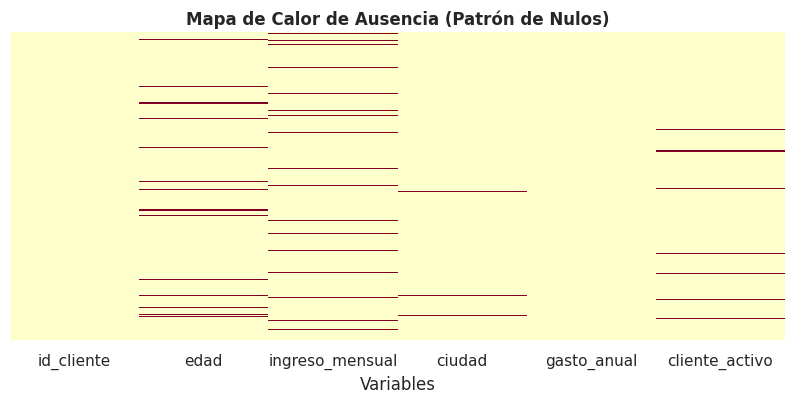

In [161]:
# Visualización del patrón de nulos
plt.figure(figsize=(10, 4))
sns.heatmap(df_raw.isnull(), cbar=False, cmap='YlOrRd', yticklabels=False)
plt.title('Mapa de Calor de Ausencia (Patrón de Nulos)', fontweight='bold')
plt.xlabel('Variables')
plt.show()

---
## 4. Detección de Anomalías e Inconsistencias de Conformidad 🚨

Auditamos las inconsistencias de conformidad semántica en edad, gasto y texto. El análisis de correlaciones y relaciones multivariadas se retoma en la Sección 5:

In [162]:
# 1. Inconsistencias de conformidad en edad (< 18 o > 100 años)
edades_raras = df_raw[(df_raw['edad'] < 18) | (df_raw['edad'] > 100)]
print(f"1. Edades no conformes detectadas: {len(edades_raras)} registros")
display(edades_raras.head(4))

# 2. Inconsistencias lógicas de consistencia (Gasto Anual negativo)
gastos_negativos = df_raw[df_raw['gasto_anual'] < 0]
print(f"\n2. Gastos negativos imposibles: {len(gastos_negativos)} registros")
display(gastos_negativos)

# 3. Inconsistencias en variables categóricas (Ciudades duplicadas por mayúsculas)
print("\n3. Categorías sucias en Ciudad:", df_raw['ciudad'].unique())

1. Edades no conformes detectadas: 25 registros


,id_cliente,edad,ingreso_mensual,ciudad,gasto_anual,cliente_activo
51,CLI-00052,999.0,6157591.09,Cali,1370765.63,Si
68,CLI-00069,999.0,3692944.14,Bogotá,540259.52,No
90,CLI-00091,-5.0,6502354.87,Medellín,2835441.68,No
180,CLI-00181,999.0,6553882.20,Tunja,134191.46,Si



2. Gastos negativos imposibles: 5 registros


,id_cliente,edad,ingreso_mensual,ciudad,gasto_anual,cliente_activo
269,CLI-00270,55.0,3400660.67,Tunja,-50000.0,Si
719,CLI-00720,56.0,7917602.98,Tunja,-50000.0,SI
721,CLI-00722,70.0,2594386.88,Bogotá,-50000.0,No
902,CLI-00903,65.0,3603864.95,Cali,-50000.0,No
1102,CLI-01103,54.0,4408623.25,Medellín,-50000.0,SI



3. Categorías sucias en Ciudad: ['Medellín' 'Tunja' 'Cali' 'Bogotá' 'tunja' 'Desconocido' 'BOGOTA' 'TUNJA'
 nan]


In [163]:
# Detección de Outliers en Ingreso con la Regla de Tukey (IQR)
q1 = df_raw['ingreso_mensual'].quantile(0.25)
q3 = df_raw['ingreso_mensual'].quantile(0.75)
iqr = q3 - q1
limite_superior = q3 + 3.0 * iqr # Outliers extremos

outliers_ingreso = df_raw[df_raw['ingreso_mensual'] > limite_superior]
print(f"Límite superior Tukey: ${limite_superior:,.2f} COP")
print(f"Outliers extremos detectados: {len(outliers_ingreso)} clientes")
display(outliers_ingreso[['id_cliente', 'ingreso_mensual', 'edad']].head(3))

Límite superior Tukey: $11,804,834.71 COP
Outliers extremos detectados: 8 clientes


,id_cliente,ingreso_mensual,edad
13,CLI-00014,85000000.0,70.0
27,CLI-00028,85000000.0,50.0
29,CLI-00030,85000000.0,NaN


In [164]:
# =============================================================================
# PIPELINE PROFESIONAL DE SANEAMIENTO Y LIMPIEZA
# =============================================================================
df_saneado = df_raw.copy()

# 1. Deduplicación
df_saneado = df_saneado.drop_duplicates(subset=['id_cliente'])

# 2. Corrección de conformidad en edad
df_saneado.loc[(df_saneado['edad'] < 18) | (df_saneado['edad'] > 100), 'edad'] = np.nan
df_saneado['edad'] = df_saneado['edad'].fillna(df_saneado['edad'].median())

# 3. Corrección de gasto negativo
df_saneado.loc[df_saneado['gasto_anual'] < 0, 'gasto_anual'] = np.nan
df_saneado['gasto_anual'] = df_saneado['gasto_anual'].fillna(df_saneado['gasto_anual'].median())

# 4. Normalización de cadenas de texto en ciudad
df_saneado['ciudad'] = df_saneado['ciudad'].astype(str).str.strip().str.upper()
df_saneado['ciudad'] = df_saneado['ciudad'].replace({'TUNJA': 'Tunja', 'BOGOTA': 'Bogotá', 'MEDELLÍN': 'Medellín', 'CALI': 'Cali'})
df_saneado['ciudad'] = df_saneado['ciudad'].replace({'DESCONOCIDO': 'Otro', 'NONE': 'Otro', 'NAN': 'Otro'})

# 5. Imputación robusta de ingresos con mediana
df_saneado['ingreso_mensual'] = df_saneado['ingreso_mensual'].clip(upper=limite_superior)
df_saneado['ingreso_mensual'] = df_saneado['ingreso_mensual'].fillna(df_saneado['ingreso_mensual'].median())

# 6. Normalización de la variable binaria cliente_activo (en crudo mezcla 'Si'/'SI'/'1'/'TRUE'/'No'/'0')
df_saneado['cliente_activo'] = df_saneado['cliente_activo'].astype(str).str.strip().str.upper()
df_saneado['cliente_activo'] = df_saneado['cliente_activo'].replace({
    'SI': 'Si', '1': 'Si', 'TRUE': 'Si',
    'NO': 'No', '0': 'No', 'FALSE': 'No', 'NAN': np.nan
})
df_saneado['cliente_activo'] = df_saneado['cliente_activo'].fillna(df_saneado['cliente_activo'].mode()[0])

print("✅ Pipeline de saneamiento ejecutado con éxito. Nuevo estado de salud:")
display(auditar_calidad_datos(df_saneado))

✅ Pipeline de saneamiento ejecutado con éxito. Nuevo estado de salud:
📋 REPORTE EJECUTIVO DE CALIDAD DEL DATO (DATA HEALTH CHECK):
• Filas Totales     : 1200
• Filas Duplicadas  : 0


,Columna,Tipo_Dato,Valores_Nulos,Porcentaje_Nulos (%),Valores_Unicos,Ejemplo_Valor
0,id_cliente,object,0,0.0,1200,CLI-00001
1,edad,float64,0,0.0,57,56.0
2,ingreso_mensual,float64,0,0.0,1134,7142533.4
3,ciudad,object,0,0.0,6,Medellín
4,gasto_anual,float64,0,0.0,1195,57055.53
5,cliente_activo,object,0,0.0,2,Si


---
## 5. Exploración Multivariada: Correlaciones y Segmentación por Variable Categórica 📊🔗

Una auditoría de calidad rigurosa no se limita a evaluar cada columna de forma aislada: también debe examinar **cómo se relacionan las variables entre sí**, pues allí suelen ocultarse las anomalías más sutiles. Dos técnicas de alto valor diagnóstico y bajo costo computacional:

* **Matriz de Correlación de Pearson:** cuantifica la fuerza y dirección de la relación lineal entre pares de variables numéricas, en un rango $[-1, 1]$. Una correlación inesperadamente alta suele delatar una fuga de información o una variable redundante; una **correlación espuria** (fuerte pero sin sentido de negocio) exige investigación adicional antes de confiar en el dato.
* **Segmentación Cruzada (*Group-by* Multivariado):** compara la distribución de variables numéricas entre los niveles de una variable categórica —aquí, `cliente_activo`— para detectar si el estado del cliente está asociado con su perfil socioeconómico.

Trabajamos sobre `df_saneado`, el dataset ya auditado y corregido en la sección anterior. Nótese que, durante el saneamiento, también se homogenizó `cliente_activo` (que en crudo mezclaba `'Si'`, `'SI'`, `'1'`, `'TRUE'`, `'No'`, `'0'` y valores nulos) a la representación binaria `Si` / `No`.

<Figure size 600x450 with 0 Axes>

<Axes: >

Text(0.5, 1.0, 'Matriz de Correlación de Pearson (Variables Numéricas)')

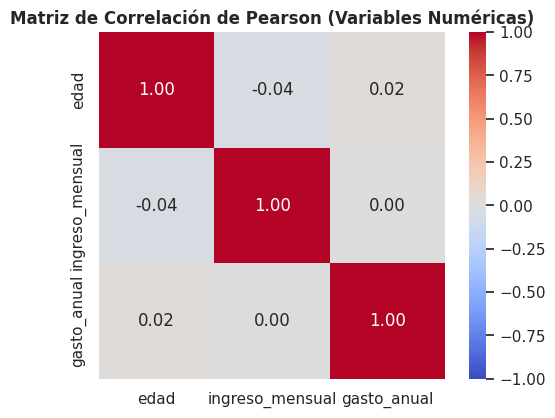

Matriz de correlación:


,edad,ingreso_mensual,gasto_anual
edad,1.000000,-0.043097,0.019240
ingreso_mensual,-0.043097,1.000000,0.001191
gasto_anual,0.019240,0.001191,1.000000


In [165]:
# Matriz de correlación de Pearson entre variables numéricas
cols_numericas = ['edad', 'ingreso_mensual', 'gasto_anual']
matriz_corr = df_saneado[cols_numericas].corr(method='pearson')

plt.figure(figsize=(6, 4.5))
sns.heatmap(matriz_corr, annot=True, fmt='.2f', cmap='coolwarm', vmin=-1, vmax=1, square=True)
plt.title('Matriz de Correlación de Pearson (Variables Numéricas)', fontweight='bold')
plt.show()

print("Matriz de correlación:")
display(matriz_corr)

<Axes: xlabel='cliente_activo', ylabel='ingreso_mensual'>

Text(0.5, 1.0, 'Ingreso Mensual por Estado de Actividad')

<Axes: xlabel='cliente_activo', ylabel='gasto_anual'>

Text(0.5, 1.0, 'Gasto Anual por Estado de Actividad')

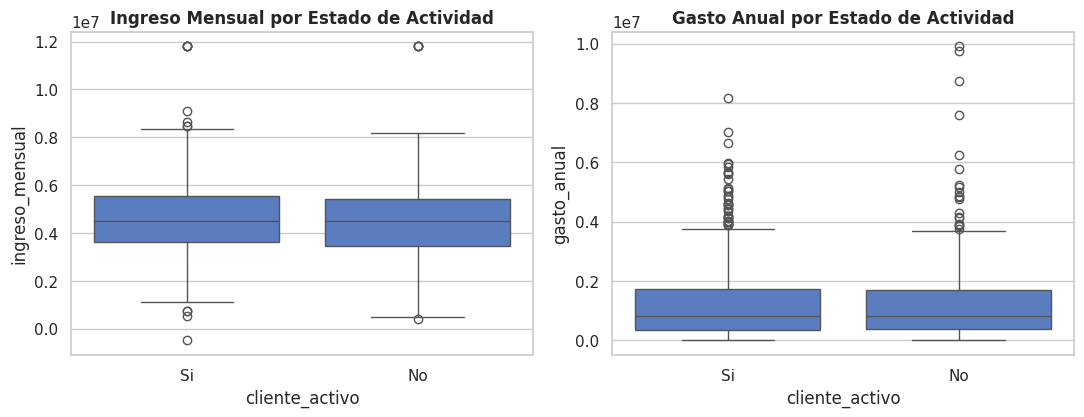

Perfil promedio por estado de actividad del cliente:


,edad,ingreso_mensual,gasto_anual
cliente_activo,,,
No,45.80,4443152.49,1220735.53
Si,46.43,4588243.60,1222157.48


In [166]:
# Segmentación multivariada: perfil de ingreso y gasto según actividad del cliente
fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))
sns.boxplot(data=df_saneado, x='cliente_activo', y='ingreso_mensual', ax=axes[0])
axes[0].set_title('Ingreso Mensual por Estado de Actividad', fontweight='bold')
sns.boxplot(data=df_saneado, x='cliente_activo', y='gasto_anual', ax=axes[1])
axes[1].set_title('Gasto Anual por Estado de Actividad', fontweight='bold')
plt.tight_layout()
plt.show()

resumen_segmentado = df_saneado.groupby('cliente_activo')[cols_numericas].mean().round(2)
print("Perfil promedio por estado de actividad del cliente:")
display(resumen_segmentado)

---
## 6. Ejercicio Práctico Guiado: Auditoría de Reglas de Consistencia 📝

**Tu misión:** Crea una regla de validación cruzada que detecte si hay clientes cuyo gasto anual supere al 90% de sus ingresos anuales estimados (`gasto_anual > ingreso_mensual * 12 * 0.90`):

Completa la celda de código siguiente reemplazando el marcador `### TU CÓDIGO AQUÍ ###`. Si te bloqueas, despliega la solución guiada que se encuentra justo debajo.

In [167]:
### TU CÓDIGO AQUÍ ###
# 1. Calcula el ingreso anual estimado de cada cliente (ingreso_mensual * 12)
# ingreso_anual_est = ...

# 2. Filtra los clientes cuyo gasto_anual supere el 90% de ese ingreso anual estimado
# inconsistencias_gasto = ...

# 3. Imprime cuántos casos se detectaron y muestra una vista previa de las columnas clave

<details>
<summary>💡 Haz clic aquí para ver la solución guiada...</summary>

```python
ingreso_anual_est = df_saneado['ingreso_mensual'] * 12
inconsistencias_gasto = df_saneado[df_saneado['gasto_anual'] > (ingreso_anual_est * 0.90)]
print(f"Clientes con ratio de gasto potencialmente insostenible (>90% ingresos): {len(inconsistencias_gasto)}")
display(inconsistencias_gasto[['id_cliente', 'ingreso_mensual', 'gasto_anual']].head(3))
```

</details>

---
## 7. Resumen Ejecutivo del Cuaderno 03 📌

1. **Auditoría Previa Obligatoria:** Ningún modelo debe entrenarse antes de ejecutar un chequeo de las 5 dimensiones de calidad del dato.
2. **El Peligro de Borrar Filas:** Si la ausencia es MAR o MNAR, borrar filas sesga la muestra poblacional.
3. **La Auditoría es Multivariada, no solo Columna a Columna:** las correlaciones entre variables y la segmentación cruzada por categorías (ej. `cliente_activo`) revelan patrones y anomalías que un chequeo univariado no detecta.
4. **Próximo Paso:** En el **Cuaderno 04** abordaremos el componente ético y legal: **Sesgo Algorítmico, Privacidad de Datos, k-Anonimato y Marcos Regulatorios (Habeas Data / GDPR)**.

---
<div align="center">
  <p style="font-size: 0.9em; color: #64748b;">
    © 2026 <b>Universidad Santo Tomás — Seccional Tunja</b><br>
    <i>Especialización en Ciencia de Datos | Asignatura: Minería de Datos (Data Mining)</i>
  </p>
</div>